In [1]:
#Om Sri Sai Ram

Data loaded successfully.
Data cleaned and mapped. Generating plots for 200 entries...


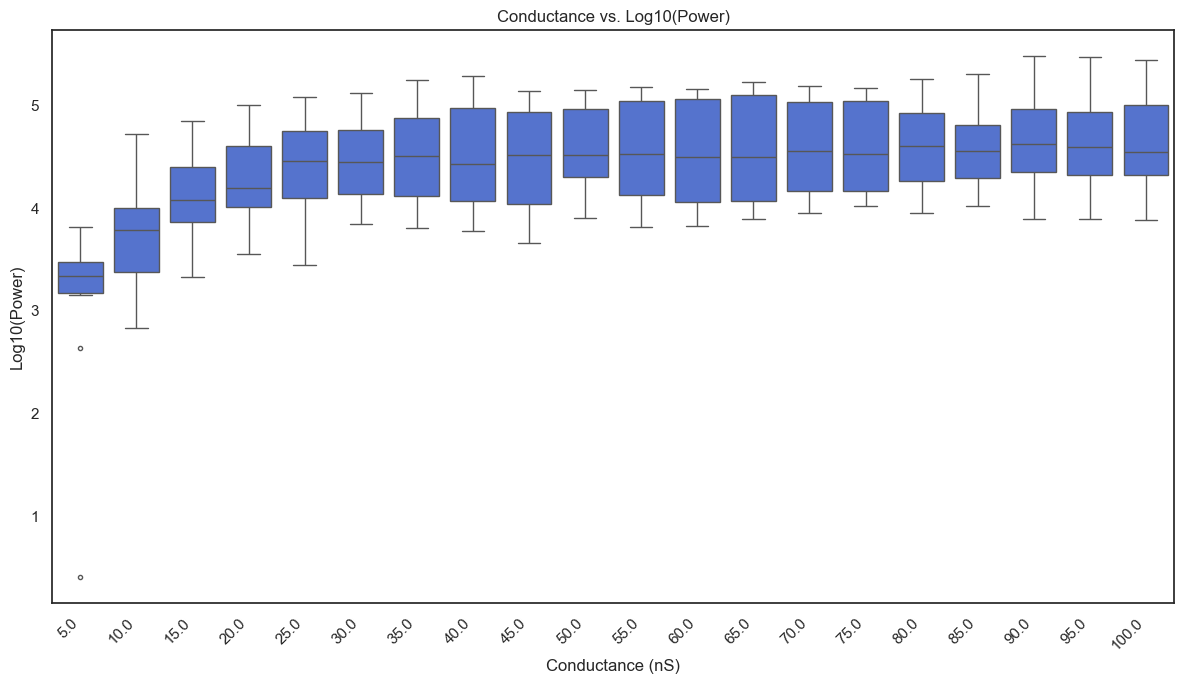

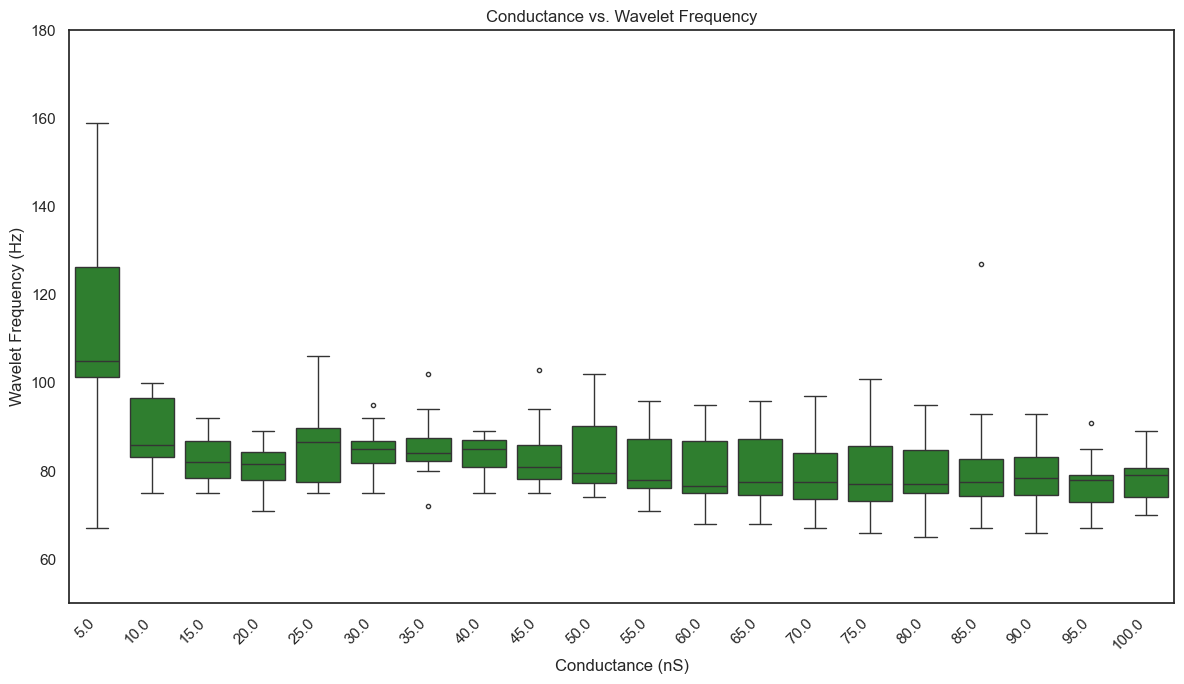

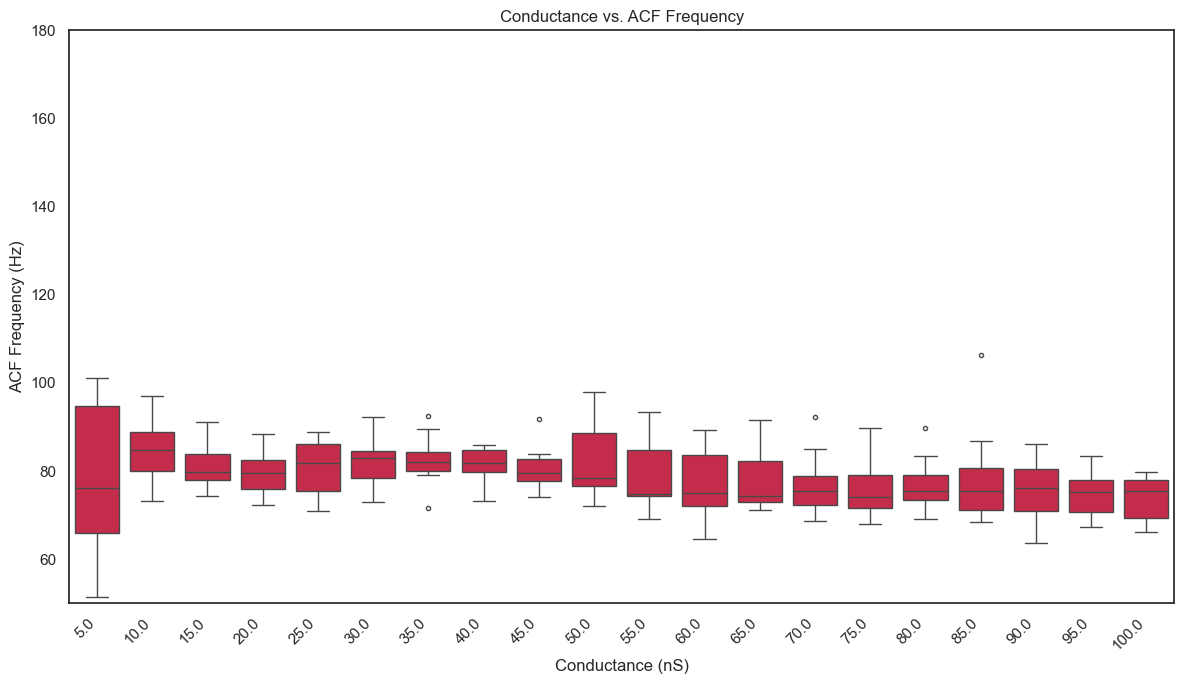

Analysis complete. Figures saved as .png and .eps in the current directory.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def analyze_and_plot_data(excel_file_path):
    """
    Reads batch data from an Excel file, mathematically parses indices, 
    calculates true conductance, and generates/saves monochromatic box plots.
    """
    try:
        # 1. Read the Excel file without headers and explicitly assign names
        df = pd.read_excel(excel_file_path, header=None, 
                           names=['Index', 'Power', 'Wavelet_Freq', 'ACF_Freq'])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print(f"Error: File not found at {excel_file_path}")
        return
    except Exception as e:
        print(f"Error reading Excel file: {e}")
        return

    # 2. Parse the Index mathematically
    # Seed is the integer part
    df['Seed'] = df['Index'].apply(lambda x: int(x))
    
    # Conductance Index is the decimal part * 100 (rounded to handle floating point errors)
    df['Cond_Index'] = df['Index'].apply(lambda x: int(round((x - int(x)) * 100)))

    # 3. Map to true Conductance in Nano Siemens (nS)
    # Original array: 0.00005 to 0.001 (length 20). 
    # Multiplier: * 100 (for uS) * 1000 (for nS) = * 100000
    cond_array = np.arange(0.00005, 0.00105, 0.00005)
    
    def map_conductance(idx):
        if 0 <= idx < len(cond_array):
            # Rounding to 1 decimal place keeps the x-axis labels clean (e.g., 5.0, 10.0)
            return round(cond_array[idx] * 100000, 1)
        return np.nan

    df['Conductance (nS)'] = df['Cond_Index'].apply(map_conductance)

    # 4. Data Cleaning
    # Convert metric columns to numeric
    for col in ['Power', 'Wavelet_Freq', 'ACF_Freq']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows that failed conductance mapping
    df = df.dropna(subset=['Conductance (nS)'])

    # Handle Power for Log10 Transformation (must be > 0)
    df['Power'] = df['Power'].apply(lambda x: x if x > 0 else np.nan)
    df = df.dropna(subset=['Power', 'Wavelet_Freq', 'ACF_Freq'])
    df['LogPower'] = np.log10(df['Power'])

    print(f"Data cleaned and mapped. Generating plots for {len(df)} entries...")

    # Set overall visual style for Seaborn
    sns.set_theme(style="white") 

    # --- Plot 1: Conductance vs Log10(Power) ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='Conductance (nS)', y='LogPower', color='royalblue', fliersize=3)
    plt.title('Conductance vs. Log10(Power)')
    plt.xlabel('Conductance (nS)')
    plt.ylabel('Log10(Power)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('0711_Conductance_vs_LogPower.png', dpi=300)
    plt.savefig('0711_Conductance_vs_LogPower.eps', format='eps')
    plt.show()

    # --- Plot 2: Conductance vs Wavelet Frequency ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='Conductance (nS)', y='Wavelet_Freq', color='forestgreen', fliersize=3)
    plt.title('Conductance vs. Wavelet Frequency')
    plt.xlabel('Conductance (nS)')
    plt.ylabel('Wavelet Frequency (Hz)')
    plt.ylim([50,180])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('0711_Conductance_vs_WaveletFreq.png', dpi=300)
    plt.savefig('0711_Conductance_vs_WaveletFreq.eps', format='eps')
    plt.show()

    # --- Plot 3: Conductance vs ACF Frequency ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='Conductance (nS)', y='ACF_Freq', color='crimson', fliersize=3)
    plt.title('Conductance vs. ACF Frequency')
    plt.xlabel('Conductance (nS)')
    plt.ylabel('ACF Frequency (Hz)')
    plt.ylim([50,180])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('0711_Conductance_vs_ACFFreq.png', dpi=300)
    plt.savefig('0711_Conductance_vs_ACFFreq.eps', format='eps')
    plt.show()

    print("Analysis complete. Figures saved as .png and .eps in the current directory.")


if __name__ == "__main__":
    excel_file_path = '0709_EI_Batch_Data.xlsx'
    analyze_and_plot_data(excel_file_path)

Data loaded successfully.
Data cleaned and mapped. Generating plots for 164 entries...


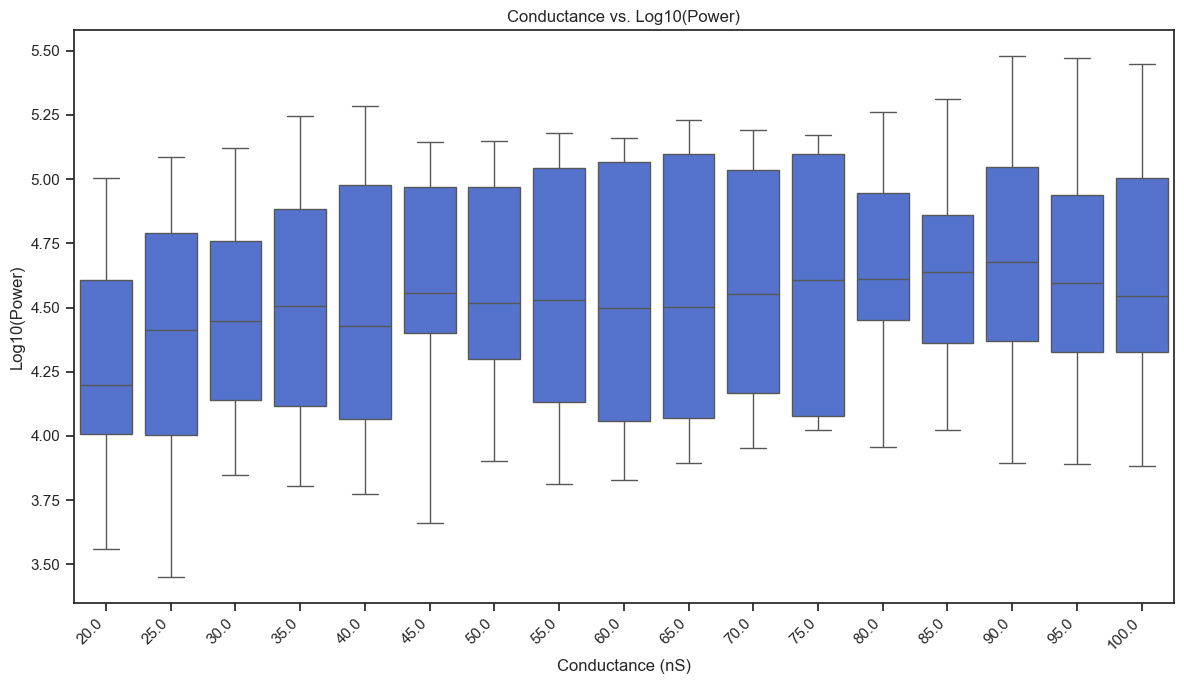

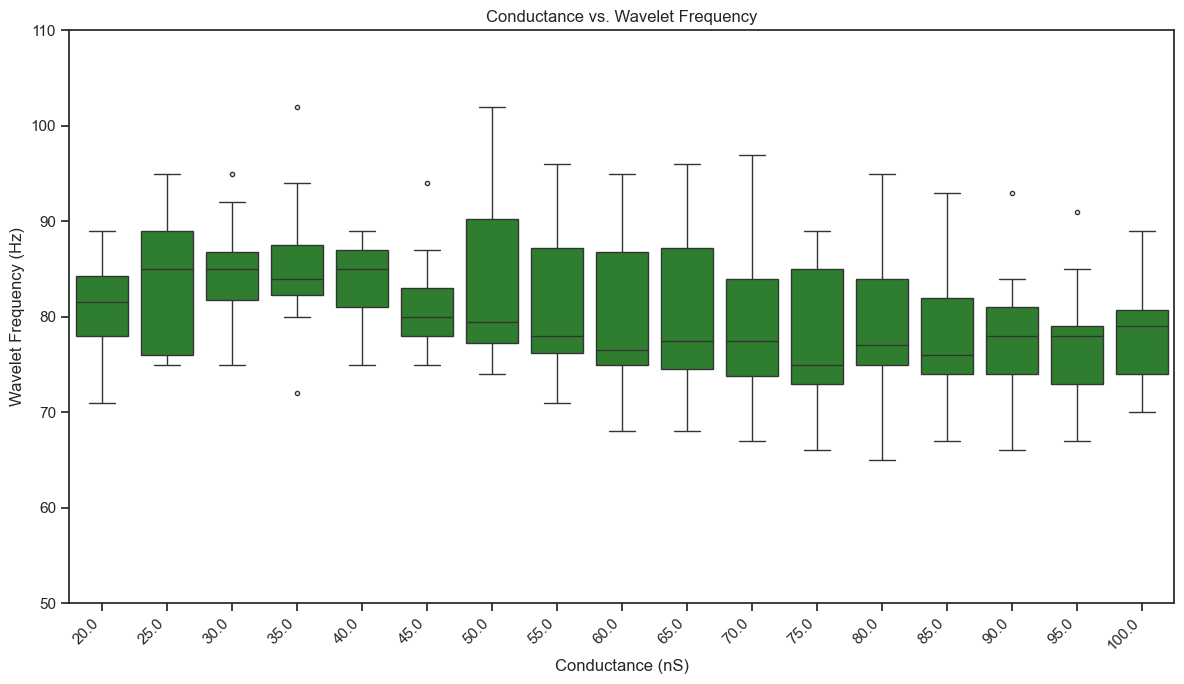

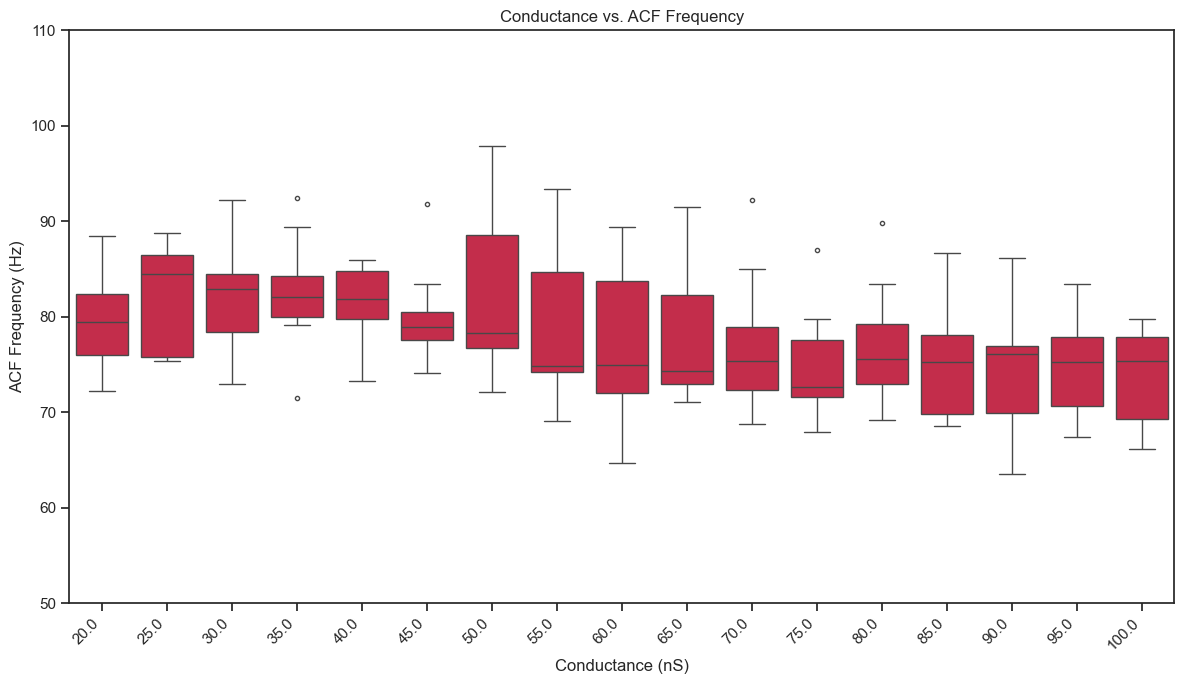

Analysis complete. Figures saved as .png and .eps in the current directory.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def analyze_and_plot_data(excel_file_path):
    """
    Reads batch data from an Excel file, mathematically parses indices, 
    calculates true conductance, and generates/saves monochromatic box plots.
    """
    try:
        # 1. Read the Excel file without headers and explicitly assign names
        df = pd.read_excel(excel_file_path, header=None, 
                           names=['Index', 'Power', 'Wavelet_Freq', 'ACF_Freq'])
        print("Data loaded successfully.")
    except FileNotFoundError:
        print(f"Error: File not found at {excel_file_path}")
        return
    except Exception as e:
        print(f"Error reading Excel file: {e}")
        return

    # 2. Parse the Index mathematically
    # Seed is the integer part
    df['Seed'] = df['Index'].apply(lambda x: int(x))
    
    # Conductance Index is the decimal part * 100 (rounded to handle floating point errors)
    df['Cond_Index'] = df['Index'].apply(lambda x: int(round((x - int(x)) * 100)))

    # --- THE NEW FILTER ---
    # Drop all rows where the Conductance Index is 0 (which corresponds to 5 nS)
    df = df[df['Cond_Index'] >= 3]

    # 3. Map to true Conductance in Nano Siemens (nS)
    # Original array: 0.00005 to 0.001 (length 20). 
    # Multiplier: * 100 (for uS) * 1000 (for nS) = * 100000
    cond_array = np.arange(0.00005, 0.00105, 0.00005)
    
    # Filter: Strict <= 10 Hz difference between Wavelet and ACF
    df['Freq_Diff'] = (df['Wavelet_Freq'] - df['ACF_Freq']).abs()
    df = df[df['Freq_Diff'] <= 10]
    
    def map_conductance(idx):
        if 0 <= idx < len(cond_array):
            # Rounding to 1 decimal place keeps the x-axis labels clean (e.g., 5.0, 10.0)
            return round(cond_array[idx] * 100000, 1)
        return np.nan

    df['Conductance (nS)'] = df['Cond_Index'].apply(map_conductance)

    # 4. Data Cleaning
    # Convert metric columns to numeric
    for col in ['Power', 'Wavelet_Freq', 'ACF_Freq']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows that failed conductance mapping
    df = df.dropna(subset=['Conductance (nS)'])

    # Handle Power for Log10 Transformation (must be > 0)
    df['Power'] = df['Power'].apply(lambda x: x if x > 0 else np.nan)
    df = df.dropna(subset=['Power', 'Wavelet_Freq', 'ACF_Freq'])
    df['LogPower'] = np.log10(df['Power'])

    print(f"Data cleaned and mapped. Generating plots for {len(df)} entries...")

    # Set overall visual style for Seaborn
    sns.set_theme(style="ticks") 

    # --- Plot 1: Conductance vs Log10(Power) ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='Conductance (nS)', y='LogPower', color='royalblue', fliersize=3)
    plt.title('Conductance vs. Log10(Power)')
    plt.xlabel('Conductance (nS)')
    plt.ylabel('Log10(Power)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    #plt.savefig('0714_Conductance_vs_LogPower.png', dpi=300)
    #plt.savefig('0714_Conductance_vs_LogPower.eps', format='eps')
    plt.show()

    # --- Plot 2: Conductance vs Wavelet Frequency ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='Conductance (nS)', y='Wavelet_Freq', color='forestgreen', fliersize=3)
    plt.title('Conductance vs. Wavelet Frequency')
    plt.xlabel('Conductance (nS)')
    plt.ylabel('Wavelet Frequency (Hz)')
    plt.ylim([50,110])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('0714_Conductance_vs_WaveletFreq.png', dpi=300)
    plt.savefig('0714_Conductance_vs_WaveletFreq.eps', format='eps')
    plt.show()

    # --- Plot 3: Conductance vs ACF Frequency ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df, x='Conductance (nS)', y='ACF_Freq', color='crimson', fliersize=3)
    plt.title('Conductance vs. ACF Frequency')
    plt.xlabel('Conductance (nS)')
    plt.ylabel('ACF Frequency (Hz)')
    plt.ylim([50,110])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('0714_Conductance_vs_ACFFreq.png', dpi=300)
    plt.savefig('0714_Conductance_vs_ACFFreq.eps', format='eps')
    plt.show()

    print("Analysis complete. Figures saved as .png and .eps in the current directory.")


if __name__ == "__main__":
    excel_file_path = '0709_EI_Batch_Data.xlsx'
    analyze_and_plot_data(excel_file_path)